# Customer Intelligence & Churn Prediction Platform

## Phase 5: Exploratory Data Analysis (EDA)

**Objective**

Explore the cleaned and engineered datasets to understand customer behavior, sales performance, product trends, payment patterns, delivery performance, and business insights through descriptive statistics and visualizations.

**Dataset**

Olist Brazilian E-Commerce Public Dataset (Processed)

**Author**

Tanish Mhatre

---

## Notebook Roadmap

**1. Load Processed Datasets**
- Load cleaned datasets for analysis.

**2. Dataset Overview**
- Verify dataset structure, dimensions, and basic information.

**3. Order Analysis**
- Analyze order status, order volume, and purchase trends.

**4. Sales Analysis**
- Explore sales distribution, revenue trends, and customer spending.

**5. Customer Analysis**
- Analyze customer purchase behavior, frequency, recency, and spending.

**6. Product Analysis**
- Explore product categories, product distribution, and sales performance.

**7. Payment Analysis**
- Analyze payment methods, installments, and payment values.

**8. Delivery Analysis**
- Examine delivery times, delays, and logistics performance.

**9. Review Analysis**
- Analyze customer ratings and review score distribution.

**10. Business Insights**
- Summarize key findings and actionable business recommendations.

---

## Import Libraries

Import the required libraries for data manipulation, visualization, and analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
## Load Processed Datasets
#Load the cleaned datasets created during the data preprocessing phase.

customers = pd.read_csv("../data/processed/customers_clean.csv")
orders = pd.read_csv("../data/processed/orders_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
sellers = pd.read_csv("../data/processed/sellers_clean.csv")

## Store Datasets

Store all datasets in a dictionary for quick access and validation.

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}

### Verify Dataset Shapes

Check whether all processed datasets have been loaded successfully.

In [5]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)


### Order Status Analysis

Analyze the distribution of order statuses to understand order fulfillment performance.

In [6]:
# Count the number of orders for each status

order_status_counts = (
    orders["order_status"]
    .value_counts()
)

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
# Calculate the percentage distribution of each order status

order_status_percentage = (
    orders["order_status"].value_counts(normalize=True)
    .mul(100)
    .round(2)
)   

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

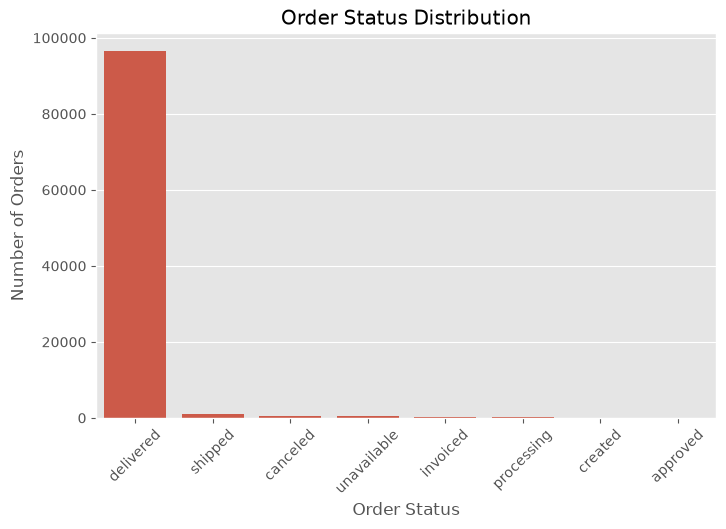

In [8]:
# Create a bar chart showing the distribution of order statuses

plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

# Add chart title and axis labels

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

# Rotate x-axis labels for better readability

plt.xticks(rotation=45)

# Display the chart

plt.show()

## Monthly Order Trend Analysis

Analyze how the number of orders changes over time to identify business growth and seasonal trends.

In [ ]:
# Convert purchase timestamp to datetime

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# Create a new column containing only the year and month

orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Count the number of orders placed in each month

monthly_orders = (
    orders
    .groupby("purchase_month")
    .size()
    .reset_index(name="total_orders")
)

# Display the first few rows

monthly_orders.head()

,purchase_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [12]:
# Convert Period to Timestamp for plotting

monthly_orders["purchase_month"] = (
    monthly_orders["purchase_month"]
    .dt.to_timestamp()
)

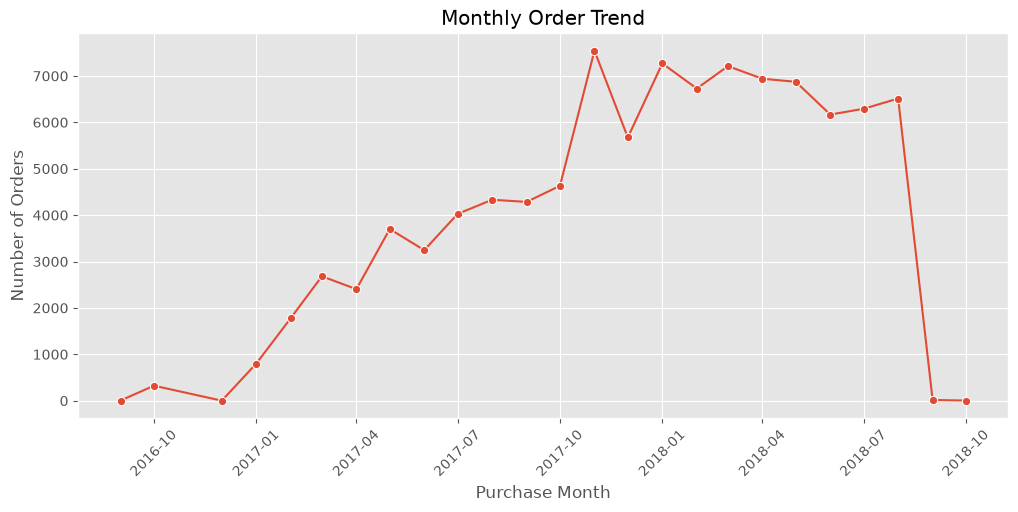

In [13]:
# Create a line chart showing monthly order trends

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="purchase_month",
    y="total_orders",
    marker="o"
)

# Add chart title and labels

plt.title("Monthly Order Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

# Rotate x-axis labels

plt.xticks(rotation=45)

# Display the chart

plt.show()

## Monthly Sales Revenue Analysis

Analyze monthly sales revenue to identify business growth, seasonal trends, and revenue performance over time.

In [14]:
# Merge orders with order items to obtain purchase date and item value

sales_data = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

# Calculate the total value of each item

sales_data["item_value"] = (
    sales_data["price"] +
    sales_data["freight_value"]
)

# Convert purchase timestamp to datetime

sales_data["order_purchase_timestamp"] = pd.to_datetime(
    sales_data["order_purchase_timestamp"]
)

# Extract purchase month

sales_data["purchase_month"] = (
    sales_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [15]:
# Calculate total revenue for each month

monthly_sales = (
    sales_data
    .groupby("purchase_month")["item_value"]
    .sum()
    .reset_index(name="total_revenue")
)

# Convert Period to Timestamp for plotting

monthly_sales["purchase_month"] = (
    monthly_sales["purchase_month"]
    .dt.to_timestamp()
)

# Display first few rows

monthly_sales.head()

,purchase_month,total_revenue
0,2016-09-01,354.75
1,2016-10-01,56808.84
2,2016-12-01,19.62
3,2017-01-01,137188.49
4,2017-02-01,286280.62


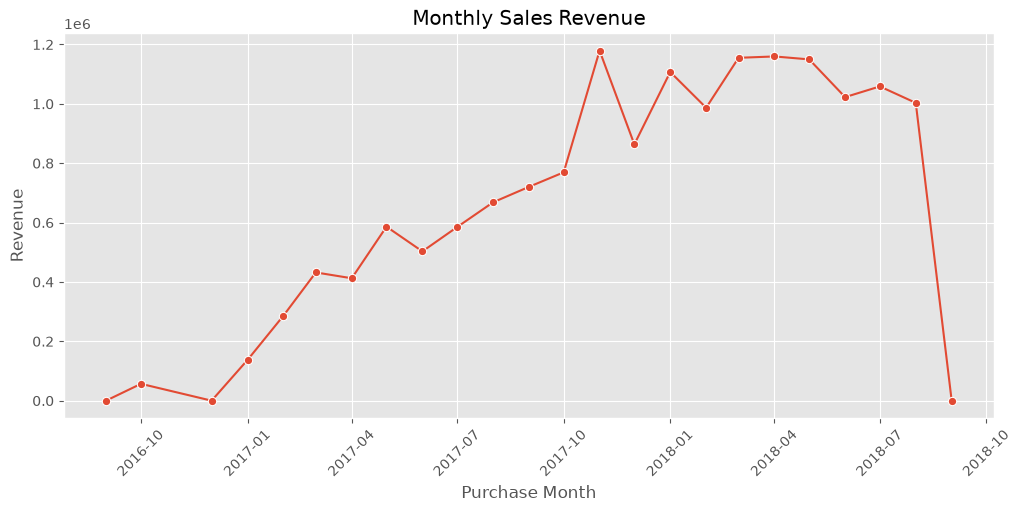

In [16]:
# Create a line chart showing monthly revenue

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="purchase_month",
    y="total_revenue",
    marker="o"
)

# Add title and labels

plt.title("Monthly Sales Revenue")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue")

# Rotate x-axis labels

plt.xticks(rotation=45)

# Display the chart

plt.show()

## Revenue Distribution Analysis

Analyze the distribution of order values to understand customer spending patterns and identify high-value orders.

## Create Analysis Tables

Create derived tables required for exploratory data analysis.


In [19]:
# Create total value for each order item

order_items["item_value"] = (
    order_items["price"] +
    order_items["freight_value"]
)

# Calculate total order value

order_value = (
    order_items
    .groupby("order_id")["item_value"]
    .sum()
    .reset_index(name="order_value")
)

# Display first few rows

order_value.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [20]:
sales_data = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

In [21]:
# Merge orders with order values

sales_data = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

# Display first few rows

sales_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,28.62


In [22]:
# Display summary statistics of order value

sales_data["order_value"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: order_value, dtype: float64

In [23]:
# Display the top 10 highest-value orders

sales_data.sort_values(
    "order_value",
    ascending=False
).head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,order_value
13390,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,2017-09,13664.08
66599,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,delivered,2018-07-15 14:49:44,2018-07-17 04:31:36,2018-07-20 13:09:00,2018-07-26 22:03:06,2018-08-02,2018-07,7274.88
22171,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,delivered,2017-02-12 20:37:36,2017-02-12 20:45:12,2017-02-16 09:23:13,2017-03-03 14:23:18,2017-03-09,2017-02,6929.31
28326,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,delivered,2018-07-25 18:10:17,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10,2018-07,6922.21
3508,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,delivered,2017-05-24 18:14:34,2017-05-26 02:45:17,2017-05-26 11:20:47,2017-06-05 17:09:48,2017-06-28,2017-05,6726.66
32322,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,delivered,2017-11-24 11:03:35,2017-11-28 12:55:46,2017-12-06 11:52:14,2017-12-13 12:16:02,2017-12-22,2017-11,6081.54
53352,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,delivered,2017-04-01 15:58:40,2017-04-03 13:25:18,2017-04-11 15:10:34,2017-04-17 11:04:45,2017-05-02,2017-04,4950.34
41086,b4c4b76c642808cbe472a32b86cddc95,e0a2412720e9ea4f26c1ac985f6a7358,canceled,2018-07-12 12:08:36,2018-07-12 12:25:53,NaN,NaN,2018-08-01,2018-07,4809.44
40327,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,delivered,2017-04-18 18:50:13,2017-04-19 15:50:15,2017-04-25 13:39:59,2017-05-07 10:42:39,2017-05-15,2017-04,4764.34
40342,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,delivered,2018-06-22 12:23:19,2018-06-22 12:36:36,2018-06-22 13:00:00,2018-07-06 01:08:30,2018-07-17,2018-06,4681.78


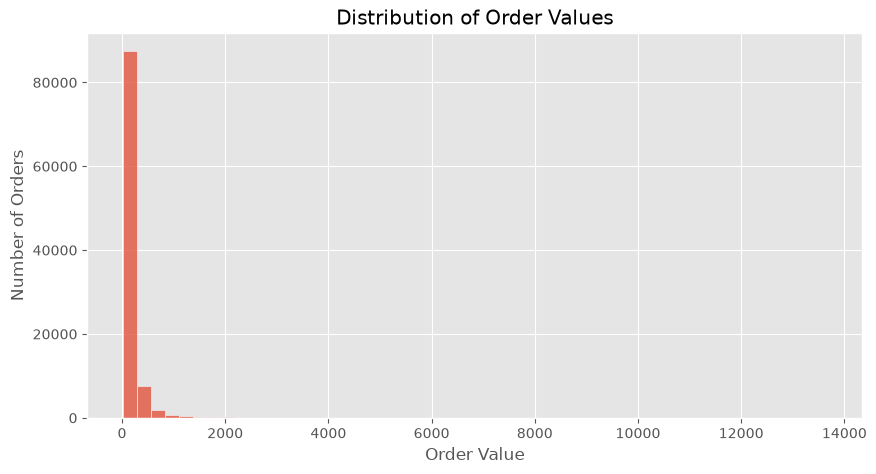

In [24]:
# Create a histogram showing the distribution of order values

plt.figure(figsize=(10, 5))

sns.histplot(
    data=sales_data,
    x="order_value",
    bins=50
)

# Add chart title and axis labels

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

# Display the chart

plt.show()

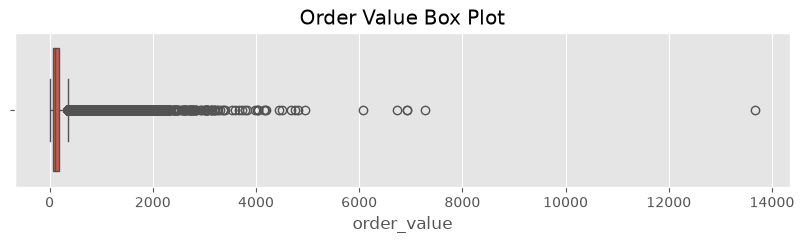

In [25]:
# Create a box plot to identify outliers

plt.figure(figsize=(10, 2))

sns.boxplot(
    x=sales_data["order_value"]
)

# Add chart title

plt.title("Order Value Box Plot")

# Display the chart

plt.show()

## Customer Spending Distribution

Analyze the total spending of customers to understand spending behavior and identify high-value customers.

In [27]:
customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

customer_features.head()

,customer_unique_id,total_orders,total_spent,average_order_value,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,336


## Monthly Revenue Trend Analysis

Analyze monthly revenue to understand business growth, sales performance, and seasonal purchasing behavior.

In [28]:
# Load engineered order value dataset

order_value = pd.read_csv(
    "../data/processed/order_value.csv"
)

# Display first few rows

order_value.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [29]:
# Combine purchase date with order value

sales_data = orders.merge(
    order_value,
    on="order_id",
    how="inner"
)

# Display first few rows

sales_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,28.62


In [30]:
# Convert purchase timestamp into datetime format

sales_data["order_purchase_timestamp"] = pd.to_datetime(
    sales_data["order_purchase_timestamp"]
)

In [31]:
# Extract purchase month

sales_data["purchase_month"] = (
    sales_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [32]:
# Calculate total revenue for each month

monthly_revenue = (
    sales_data
    .groupby("purchase_month")["order_value"]
    .sum()
    .reset_index(name="total_revenue")
)

# Display first few rows

monthly_revenue.head()

,purchase_month,total_revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62


In [33]:
# Convert Period to Timestamp for visualization

monthly_revenue["purchase_month"] = (
    monthly_revenue["purchase_month"]
    .dt.to_timestamp()
)

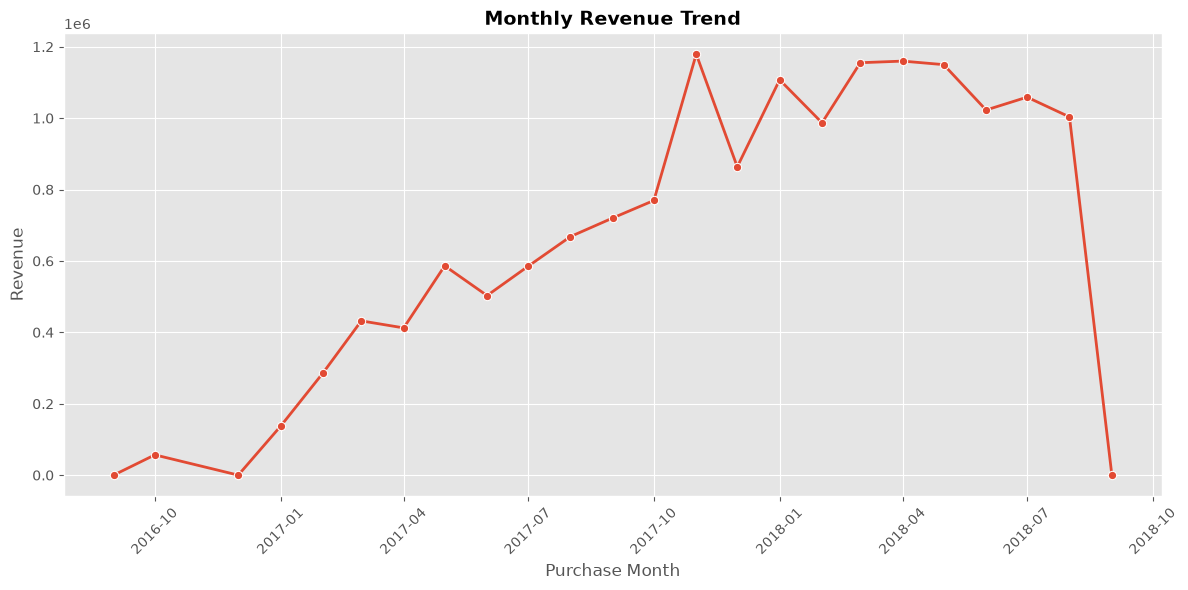

In [34]:
# Create figure

plt.figure(figsize=(12,6))

# Plot monthly revenue

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="total_revenue",
    marker="o",
    linewidth=2
)

# Add title

plt.title(
    "Monthly Revenue Trend",
    fontsize=14,
    fontweight="bold"
)

# Add axis labels

plt.xlabel("Purchase Month")
plt.ylabel("Revenue")

# Rotate labels

plt.xticks(rotation=45)

# Adjust layout

plt.tight_layout()

# Display chart

plt.show()

## Customer Spending Analysis

Analyze customer spending behavior to understand spending distribution and identify high-value customers.

In [35]:
# Load engineered customer features

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

# Display first few rows

customer_features.head()

,customer_unique_id,total_orders,total_spent,average_order_value,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,336


In [36]:
# Display summary statistics of customer spending

customer_features["total_spent"].describe()

count    96096.000000
mean       164.872141
std        227.938658
min          0.000000
25%         62.390000
50%        107.270000
75%        182.237500
max      13664.080000
Name: total_spent, dtype: float64

In [37]:
# Display top 10 customers based on total spending

customer_features.sort_values(
    by="total_spent",
    ascending=False
).head(10)

,customer_unique_id,total_orders,total_spent,average_order_value,recency_days
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,383
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,564
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,94
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,611
26205,459bef486812aa25204be022145caa62,1,6922.21,6922.210,83
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.660,510
24121,4007669dec559734d6f53e029e360987,1,6081.54,6081.540,327
35070,5d0a2980b292d049061542014e8960bf,1,4809.44,4809.440,97
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.340,546
27441,48e1ac109decbb87765a3eade6854098,1,4681.78,4681.780,117


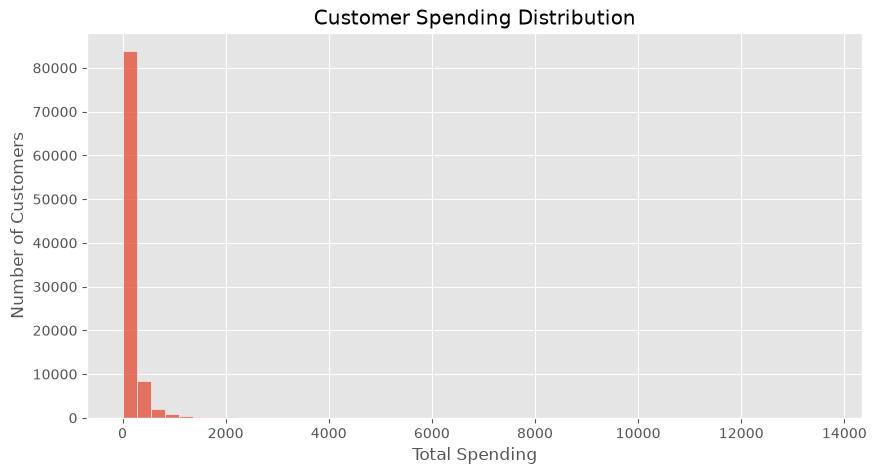

In [38]:
# Create a histogram showing customer spending distribution

plt.figure(figsize=(10,5))

sns.histplot(
    data=customer_features,
    x="total_spent",
    bins=50
)

# Add title and labels

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

# Display chart

plt.show()

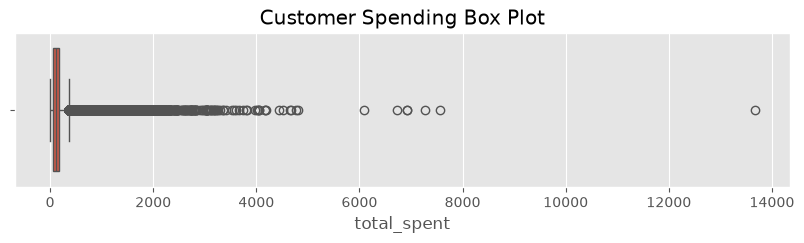

In [39]:
# Create a box plot to identify spending outliers

plt.figure(figsize=(10,2))

sns.boxplot(
    x=customer_features["total_spent"]
)

# Add title

plt.title("Customer Spending Box Plot")

# Display chart

plt.show()

## Customer Order Frequency Analysis

Analyze customer purchase frequency to understand repeat purchasing behavior and customer loyalty.

In [40]:
# Count customers by number of orders

customer_features["total_orders"].value_counts().sort_index()

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

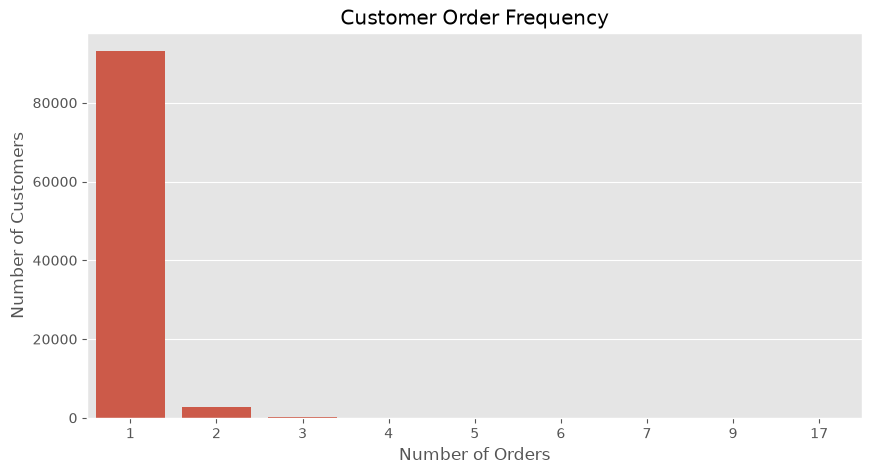

In [41]:
# Visualize customer order frequency

plt.figure(figsize=(10, 5))

sns.countplot(
    data=customer_features,
    x="total_orders"
)

plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

# Count the number of transactions for each payment method

payment_method_counts = (
    payments["payment_type"]
    .value_counts()
)

# Display the result

payment_method_counts

In [42]:
# Count the number of transactions for each payment method

payment_method_counts = (
    payments["payment_type"]
    .value_counts()
)

# Display the result

payment_method_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

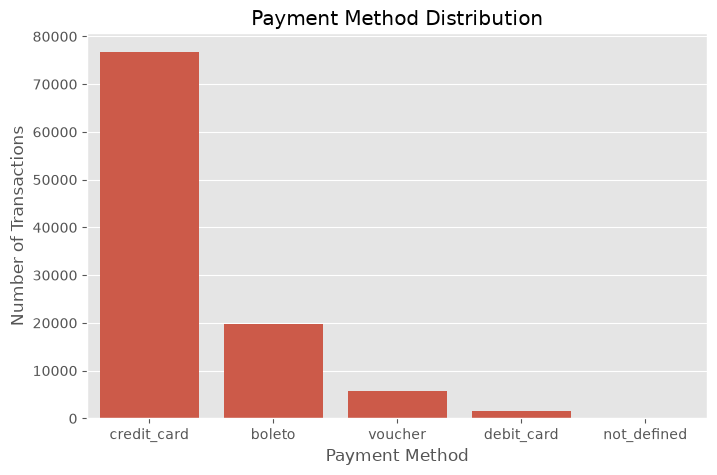

In [43]:
# Create a bar chart showing payment method distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=payments,
    x="payment_type",
    order=payment_method_counts.index
)

# Add chart title and labels

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

In [44]:
# Calculate percentage distribution of payment methods

(
    payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

## Payment Installment Analysis

Analyze the number of installments selected by customers to understand payment behavior.

In [45]:
# Count the number of transactions for each installment option

installment_counts = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
)

# Display the result

installment_counts

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

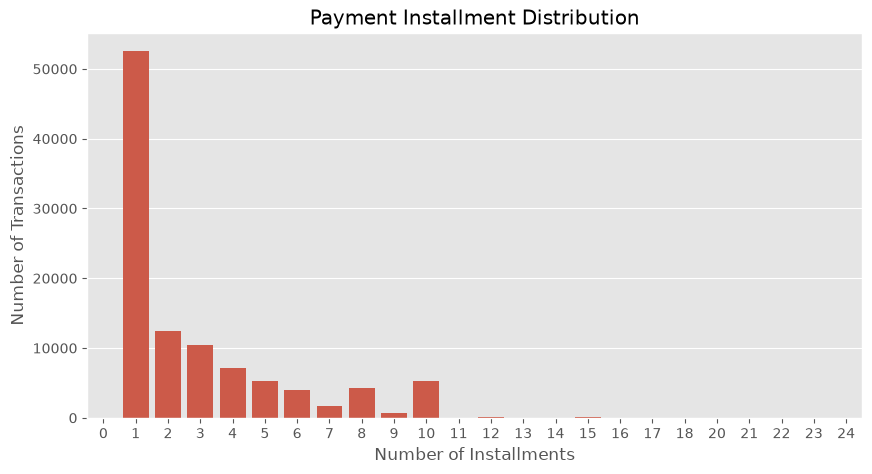

In [46]:
# Create bar chart for payment installments

plt.figure(figsize=(10,5))

sns.barplot(
    x=installment_counts.index,
    y=installment_counts.values
)

# Add chart title and labels

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Transactions")

plt.show()

In [47]:
# Display summary statistics

payments["payment_installments"].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

## Payment Value Analysis

Analyze payment values to understand transaction size distribution and identify high-value payments.

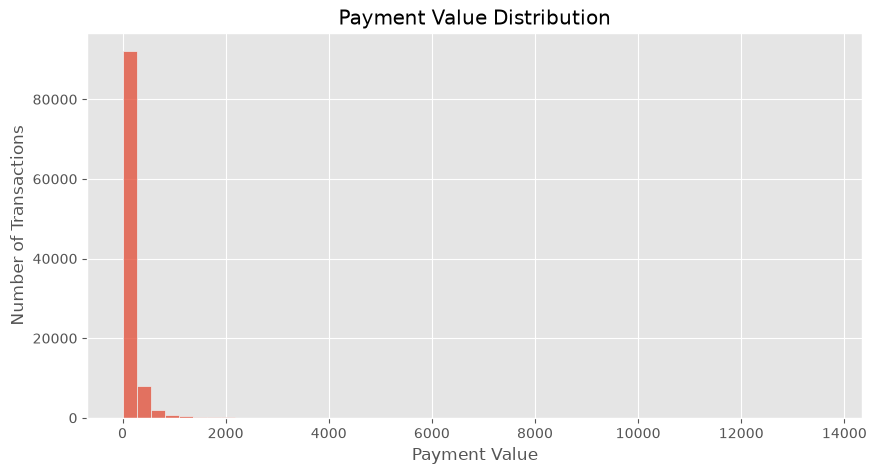

In [48]:
# Create histogram of payment values

plt.figure(figsize=(10,5))

sns.histplot(
    data=payments,
    x="payment_value",
    bins=50
)

# Add chart title and labels

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Number of Transactions")

plt.show()


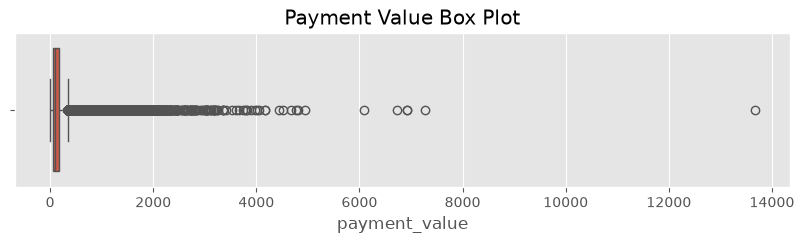

In [49]:
# Create box plot to identify outliers

plt.figure(figsize=(10,2))

sns.boxplot(
    x=payments["payment_value"]
)

# Add chart title

plt.title("Payment Value Box Plot")

plt.show()

## Product Category Analysis

Analyze product categories to identify the most frequently purchased categories.

In [50]:
# Combine order items with product information

product_sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)

# Count products sold by category

category_sales = (
    product_sales["product_category_name"]
    .value_counts()
    .head(10)
)

category_sales

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

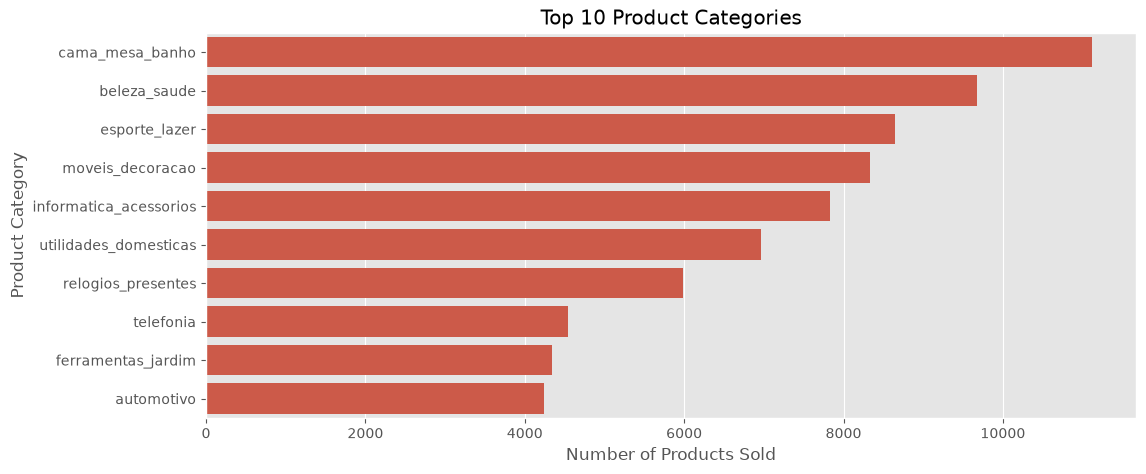

In [51]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products Sold")
plt.ylabel("Product Category")

plt.show()

## Product Category Analysis

Analyze product categories to identify the most frequently purchased product categories.

In [56]:
# Count top 10 selling product categories

category_sales = (
    product_sales["product_category_name"]
    .value_counts()
    .head(10)
)

category_sales

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

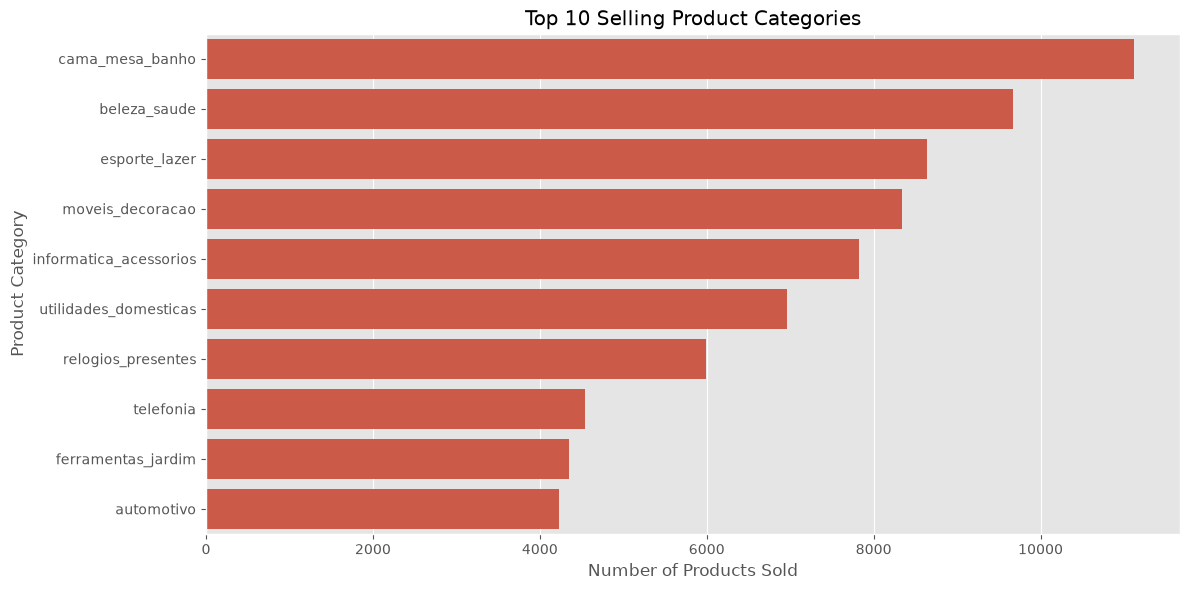

In [57]:
# Visualize top selling product categories

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Top 10 Selling Product Categories")
plt.xlabel("Number of Products Sold")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

## Customer Review Analysis

Analyze customer review scores to understand overall customer satisfaction.

In [58]:
# Count review scores

review_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

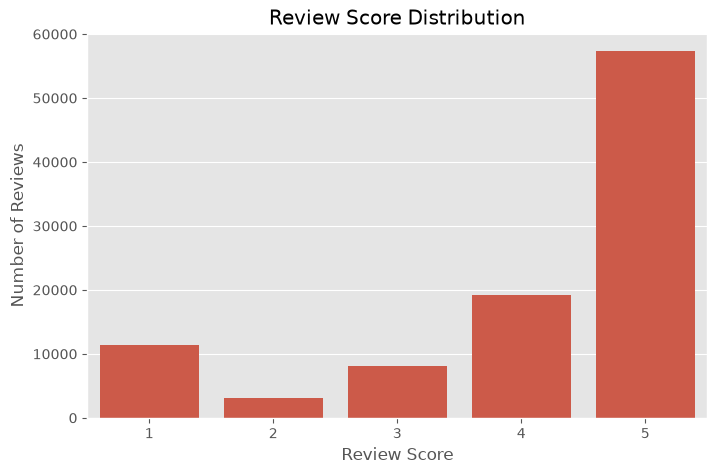

In [59]:
# Visualize review score distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

## Correlation Analysis

Analyze relationships between engineered customer features using a correlation matrix.

In [60]:
# Calculate correlation between customer features

correlation = customer_features[
    [
        "total_orders",
        "total_spent",
        "average_order_value",
        "recency_days"
    ]
].corr()

# Display correlation matrix

correlation

,total_orders,total_spent,average_order_value,recency_days
total_orders,1.000000,0.122369,-0.010593,-0.024859
total_spent,0.122369,1.000000,0.981798,-0.006060
average_order_value,-0.010593,0.981798,1.000000,-0.002276
recency_days,-0.024859,-0.006060,-0.002276,1.000000


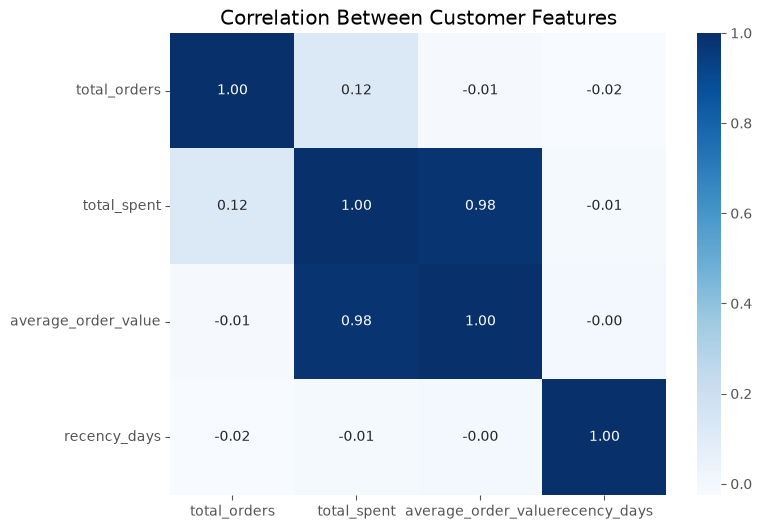

In [61]:
# Create correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

# Add title

plt.title("Correlation Between Customer Features")

plt.show()

### Key Business Insights

1. The majority of orders were successfully delivered, indicating an efficient order fulfillment process.

2. Monthly orders and revenue showed overall business growth during the observed period.

3. Most customers placed only one order, indicating a low repeat purchase rate and an opportunity to improve customer retention.

4. Customer spending is highly skewed, with a small group of customers contributing a significant portion of total revenue.

5. Credit cards are the most preferred payment method, making them the dominant payment option.

6. Most customers prefer paying in one installment, while higher installment options are used less frequently.

7. A few product categories account for a large share of total sales, indicating strong customer demand in those categories.

8. Customer review scores are generally positive, suggesting a satisfactory shopping experience for most customers.

9. Correlation analysis shows that customers with more orders generally spend more, highlighting the value of retaining repeat customers.

10. The business can improve long-term growth by increasing customer retention, promoting repeat purchases, and targeting high-value customer segments.